(<Figure size 640x480 with 2 Axes>, <Axes: xlabel='x', ylabel='y'>)

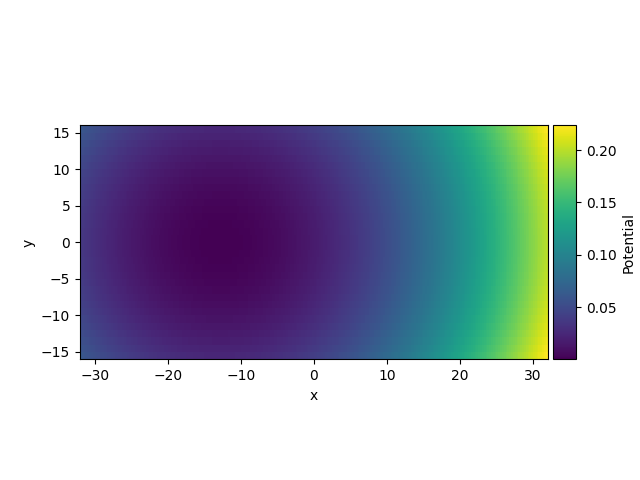

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from bloch_schrodinger.potential import Potential, create_parameter
from BECs.groundstate import GroundStateSSFM, normalize
from BECs.ufuncs import ramp

%matplotlib widget

lx, ly = 64,32
nres = 5

trap = Potential(
    [[lx,0],[0,ly]],
    (2**(nres+3), 2**(nres)),
    v0 = 0
)

omegax, omegay = 1e-4, 1e-4

trap.add(
    (trap.x+lx/5)**2 * omegax + (trap.y)**2 * omegay
)

trap.plot()

In [4]:
# Computing the ground state of the trap for 1000 atoms and two values of the interaction
g = create_parameter('g', np.linspace(-1.2, -1, 5))

grd = GroundStateSSFM(
    trap, 1, g
)

energies, psi0 = grd.solve(
    10, tol_adapt = 1e-8, tol_stop = 1e-12, parallelize=True, n_cores = 5
)


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:   10.5s remaining:   15.7s
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:   25.2s finished


Reshaping and storing


100%|██████████| 5/5 [00:00<00:00, 1362.23it/s]


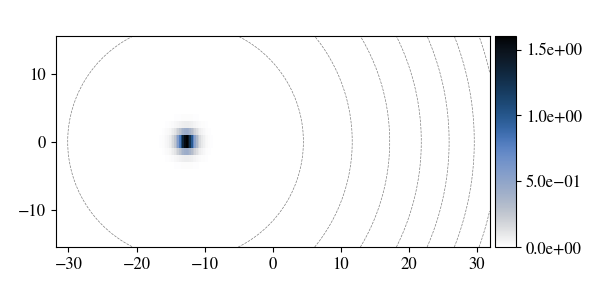

In [5]:

from bloch_schrodinger.plotting import plot_cuts, plot_eigenvector
%matplotlib widget


fig, axes = plot_eigenvector(
    [[abs(psi0)**2]],
    [[trap]],
    [['amplitude']]
)
plt.show()

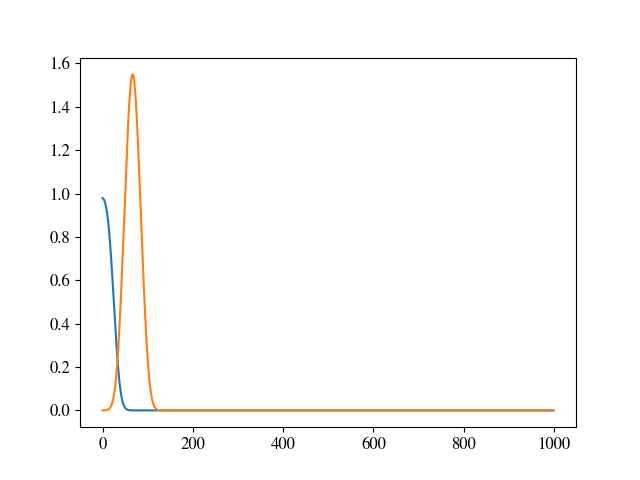

In [6]:
trap_t = trap.copy()

ti, t2, t3, t4, t5, tf = 0, 0.5, 1, 2, 3, 30 # Initial and final time of the 


t_pot = create_parameter('t', np.linspace(ti,tf,1000))
slope = create_parameter('slope', np.linspace(0.5,5,5))

harm_ramp = ramp(t_pot, 1,0,t2,t3, smooth=10)
trap_t.multiply(harm_ramp)

lin_ramp = ramp(t_pot, 0,2, t3,t4, smooth=10) * ramp(t_pot, 1,0,t4,t5, smooth=10)
trap_t.add(-(trap_t.x+lx/4) * slope * lin_ramp)

plt.close()
plt.close()
plt.close()
plt.plot(harm_ramp)
plt.plot(lin_ramp)
plt.show()

In [7]:


from BECs.ssfm import SSFM
t_samples = create_parameter('t', np.linspace(ti,tf, 300))

solv = SSFM(
    trap_t, psi0, 1, g
)



In [ ]:

psi = solv.solve(
    t_init=ti,
    t_final=tf,
    t_samples=t_samples,
    parallelize=True,
    n_cores=-1,
    verbose=False
)

[<function PotentialT.make_Vt.<locals>.Vt at 0x0000023F632F2350>, <function PotentialT.make_Vt.<locals>.Vt at 0x0000023F632F2B90>, <function PotentialT.make_Vt.<locals>.Vt at 0x0000023F632F2E50>, <function PotentialT.make_Vt.<locals>.Vt at 0x0000023F632F3060>, <function PotentialT.make_Vt.<locals>.Vt at 0x0000023F632F3270>, <function PotentialT.make_Vt.<locals>.Vt at 0x0000023F632F3480>, <function PotentialT.make_Vt.<locals>.Vt at 0x0000023F632F3690>, <function PotentialT.make_Vt.<locals>.Vt at 0x0000023F632F38A0>, <function PotentialT.make_Vt.<locals>.Vt at 0x0000023F632F3AB0>, <function PotentialT.make_Vt.<locals>.Vt at 0x0000023F632F3CC0>, <function PotentialT.make_Vt.<locals>.Vt at 0x0000023F632F3ED0>, <function PotentialT.make_Vt.<locals>.Vt at 0x0000023F640241A0>, <function PotentialT.make_Vt.<locals>.Vt at 0x0000023F640243B0>, <function PotentialT.make_Vt.<locals>.Vt at 0x0000023F640245C0>, <function PotentialT.make_Vt.<locals>.Vt at 0x0000023F640247D0>, <function PotentialT.mak

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  32 tasks      | elapsed:   24.1s
[Parallel(n_jobs=-1)]: Done 122 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 248 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 410 tasks      | elapsed:  4.1min


In [ ]:
# amp = get_template('amplitude')
# amp['contourkwargs']["levels"] = None

# real = get_template('real')
# real['contourkwargs']["levels"] = None


fig, axes = plot_eigenvector(
    [[abs(psi)**2, psi.real]],
    [[None, None]],
    [['amplitude', 'real']]
)
plt.show()

NameError: name 'psi' is not defined

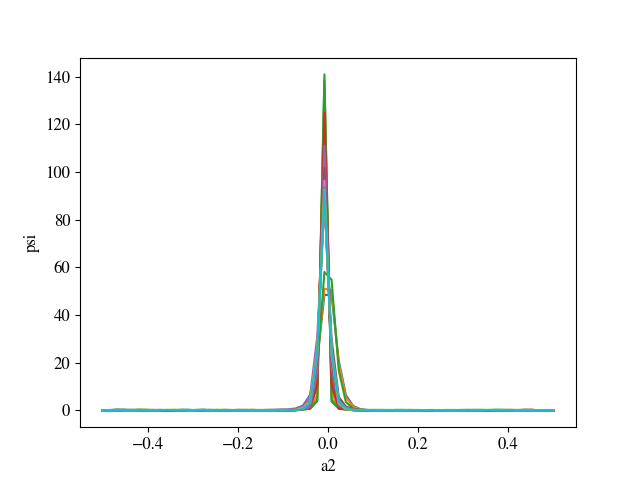

In [ ]:
fig, ax = plot_cuts(
    (abs(psi[::10,...])**2).sum('a1'),
    'a2',
    groupby=['t'],
    # ymin = -1e-1,
    # ymax = 5e-1
)
plt.show()